In [ ]:
import altair as alt
import marimo as mo
import numpy as np
import polars as pl
from scipy import stats

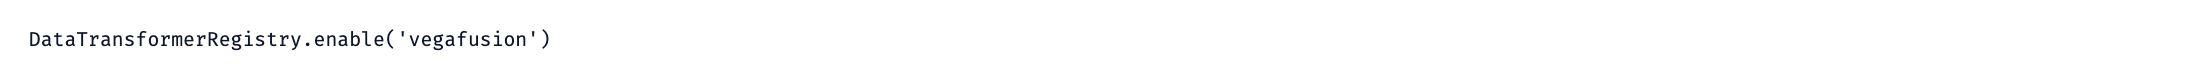

In [ ]:
alt.data_transformers.enable("vegafusion")

# Bayesian vs. Frequentist A/B Testing

A/B testing is the cornerstone of data-driven decision making. When comparing two variants (A and B),
we want to know: **Is one better than the other?**

This notebook demonstrates two fundamentally different approaches to answering this question:

| Approach | Question Answered | Output |
|----------|-------------------|--------|
| **Frequentist** | "If there's no difference, how unlikely is this data?" | p-value |
| **Bayesian** | "Given this data, what's the probability A > B?" | Direct probability |

---

## The Fundamental Difference

**Frequentist statistics** treats parameters (like true conversion rates) as fixed but unknown values.
We can only make probability statements about *data*, not parameters. The p-value tells us:
"If the null hypothesis were true, what's the probability of seeing data this extreme?"

**Bayesian statistics** treats parameters as random variables with probability distributions.
We start with a *prior belief* about the parameter, then update it with observed data to get a
*posterior distribution*. This lets us directly answer: "What's the probability that A > B?"

## Why Consider Bayesian Methods for A/B Testing?

1. **Intuitive interpretation**: "There's an 87% chance A is better" is easier to understand than "p = 0.03"
2. **Works with small samples**: Priors regularize estimates when data is limited
3. **No arbitrary thresholds**: No need to pick α = 0.05; you get a full probability distribution
4. **Incorporate domain knowledge**: Use informative priors when you have historical data
5. **Continuous monitoring**: Can check results anytime without "peeking" penalties

## Try These Example Configurations

| Scenario | Settings | What to observe |
|----------|----------|-----------------|
| **Uniform prior** | α=1, β=1 for both | Posterior ≈ sample mean (data dominates) |
| **Informative prior** | α=2, β=100 | Prior pulls estimate toward ~2% conversion |
| **Small samples** | n=50 for both | Wider posteriors, more uncertainty |
| **Unequal samples** | n_a=10000, n_b=100 | Different confidence levels per group |
| **No real difference** | mean_a = mean_b = 0.01 | Methods should show ~50% probability |

In [ ]:
# Utility: Generate binary outcomes from a binomial distribution
def sample_binomial_distribution(n: int, p: float, seed: int = 42) -> np.ndarray:
    rng = np.random.default_rng(seed=seed)
    return rng.binomial(1, p, size=n)

---

# Simulation Setup

## Ground Truth Parameters

In a real A/B test, we don't know the true conversion rates—that's what we're trying to estimate!
But in this simulation, we set them explicitly so we can see how well each method recovers the truth.

- **Mean A/B**: The *true* underlying conversion probability for each group
- **Samples**: Number of users/trials in each group

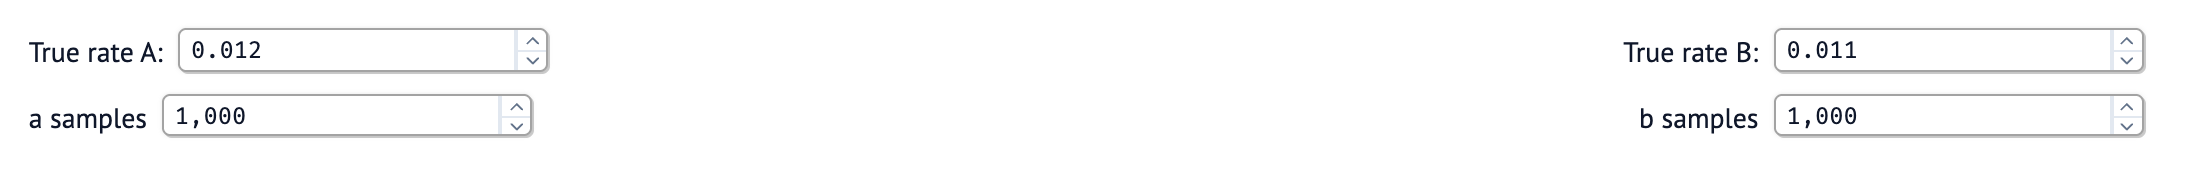

In [ ]:
true_mean_a_input = mo.ui.number(start=0, stop=1, value=0.012, label="True rate A:")
true_mean_b_input = mo.ui.number(start=0, stop=1, value=0.011, label="True rate B:")

n_a_input = mo.ui.number(
    start=0, stop=1_000_000, value=1000, step=1, label="a samples"
)
n_b_input = mo.ui.number(
    start=0, stop=1_000_000, value=1000, step=1, label="b samples"
)

mo.vstack(
    [
        mo.hstack([true_mean_a_input, true_mean_b_input]),
        mo.hstack([n_a_input, n_b_input]),
    ]
)

In [ ]:
true_mean_a = true_mean_a_input.value
true_mean_b = true_mean_b_input.value

n_a = n_a_input.value
n_b = n_b_input.value

---

## Bayesian Priors

A **prior distribution** encodes our beliefs about a parameter *before* seeing any data.
For conversion rates (bounded between 0 and 1), we use the **Beta distribution**, parameterized by α and β.

**Interpreting α and β:**
- Think of α as "prior successes" and β as "prior failures"
- α = β = 1 → Uniform prior (no prior knowledge)
- α = 2, β = 98 → Prior belief centered around 2% conversion
- Higher α + β → Stronger prior (harder for data to override)

The prior mean is α / (α + β). For example, α=2, β=98 gives a prior mean of 0.02 (2%).

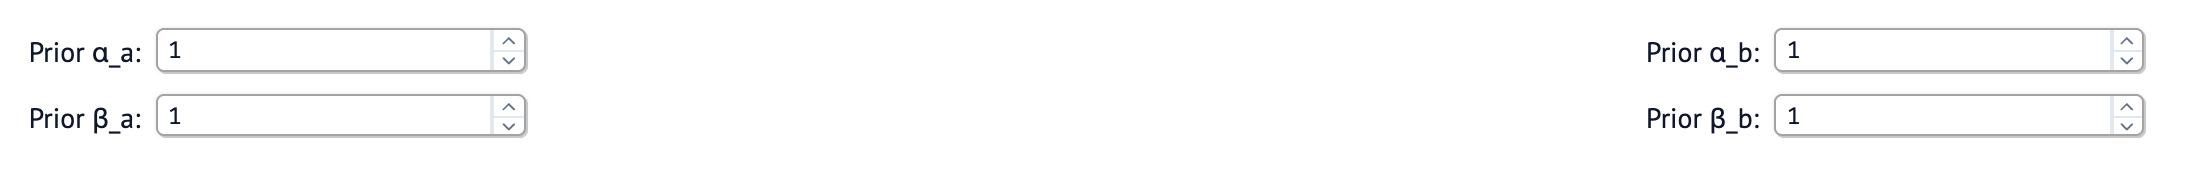

In [ ]:
prior_alpha_a_input = mo.ui.number(
    start=0.01, stop=100, value=1, label="Prior α_a:"
)
prior_beta_a_input = mo.ui.number(start=0.01, stop=100, value=1, label="Prior β_a:")
prior_alpha_b_input = mo.ui.number(
    start=0.01, stop=100, value=1, label="Prior α_b:"
)
prior_beta_b_input = mo.ui.number(start=0.01, stop=100, value=1, label="Prior β_b:")

mo.vstack(
    [
        mo.hstack([prior_alpha_a_input, prior_alpha_b_input]),
        mo.hstack([prior_beta_a_input, prior_beta_b_input]),
    ]
)

In [ ]:
prior_alpha_a = prior_alpha_a_input.value
prior_beta_a = prior_beta_a_input.value
prior_alpha_b = prior_alpha_b_input.value
prior_beta_b = prior_beta_b_input.value

### Prior Distributions Visualization

The plot below shows your chosen prior distributions. With uniform priors (α=β=1),
the distribution is flat—we're saying all conversion rates are equally likely *a priori*.
With informative priors, the distribution concentrates around your prior belief.

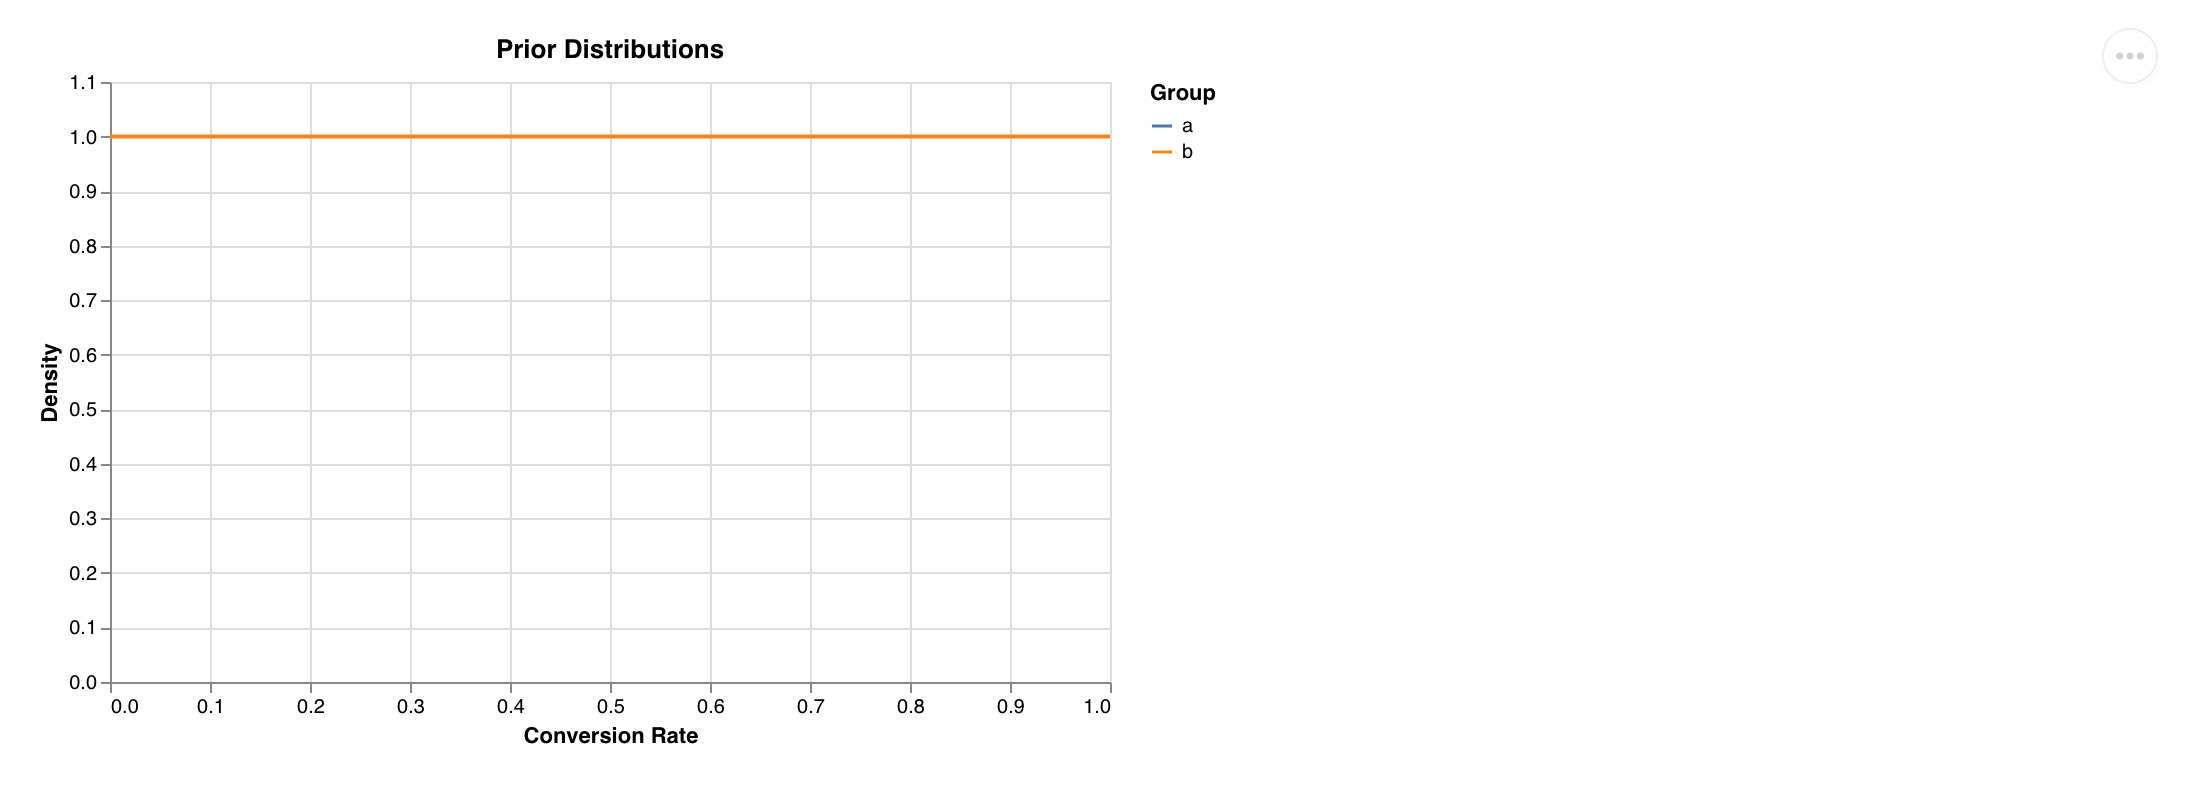

In [ ]:
def prior_pdf(alpha, beta, n_points=500):
    """Compute the PDF of a Beta prior distribution for visualization."""
    prior = stats.beta(alpha, beta)
    mean = prior.mean()
    std = prior.std()
    x = np.linspace(max(0, mean - 4 * std), min(1, mean + 4 * std), n_points)
    return x, prior.pdf(x)

x_prior_a, pdf_prior_a = prior_pdf(prior_alpha_a, prior_beta_a)
x_prior_b, pdf_prior_b = prior_pdf(prior_alpha_b, prior_beta_b)

prior_df = pl.concat(
    [
        pl.DataFrame({"group": "a", "x": x_prior_a, "density": pdf_prior_a}),
        pl.DataFrame({"group": "b", "x": x_prior_b, "density": pdf_prior_b}),
    ]
)

(
    alt.Chart(prior_df, title="Prior Distributions")
    .mark_line()
    .encode(
        x=alt.X("x:Q", title="Conversion Rate"),
        y=alt.Y("density:Q", title="Density"),
        color=alt.Color("group:N", title="Group"),
    )
    .properties(width=500, height=300)
)

---

# Observed Data

We simulate user behavior by drawing from binomial distributions with the true conversion rates.
Each "trial" represents a user who either converts (1) or doesn't (0).

In practice, this is your actual A/B test data—users assigned to variant A or B and whether they converted.

In [ ]:
# Generate synthetic A/B test data from binomial distributions
group_a = sample_binomial_distribution(n=n_a, p=true_mean_a, seed=42)
group_b = sample_binomial_distribution(n=n_b, p=true_mean_b, seed=43)

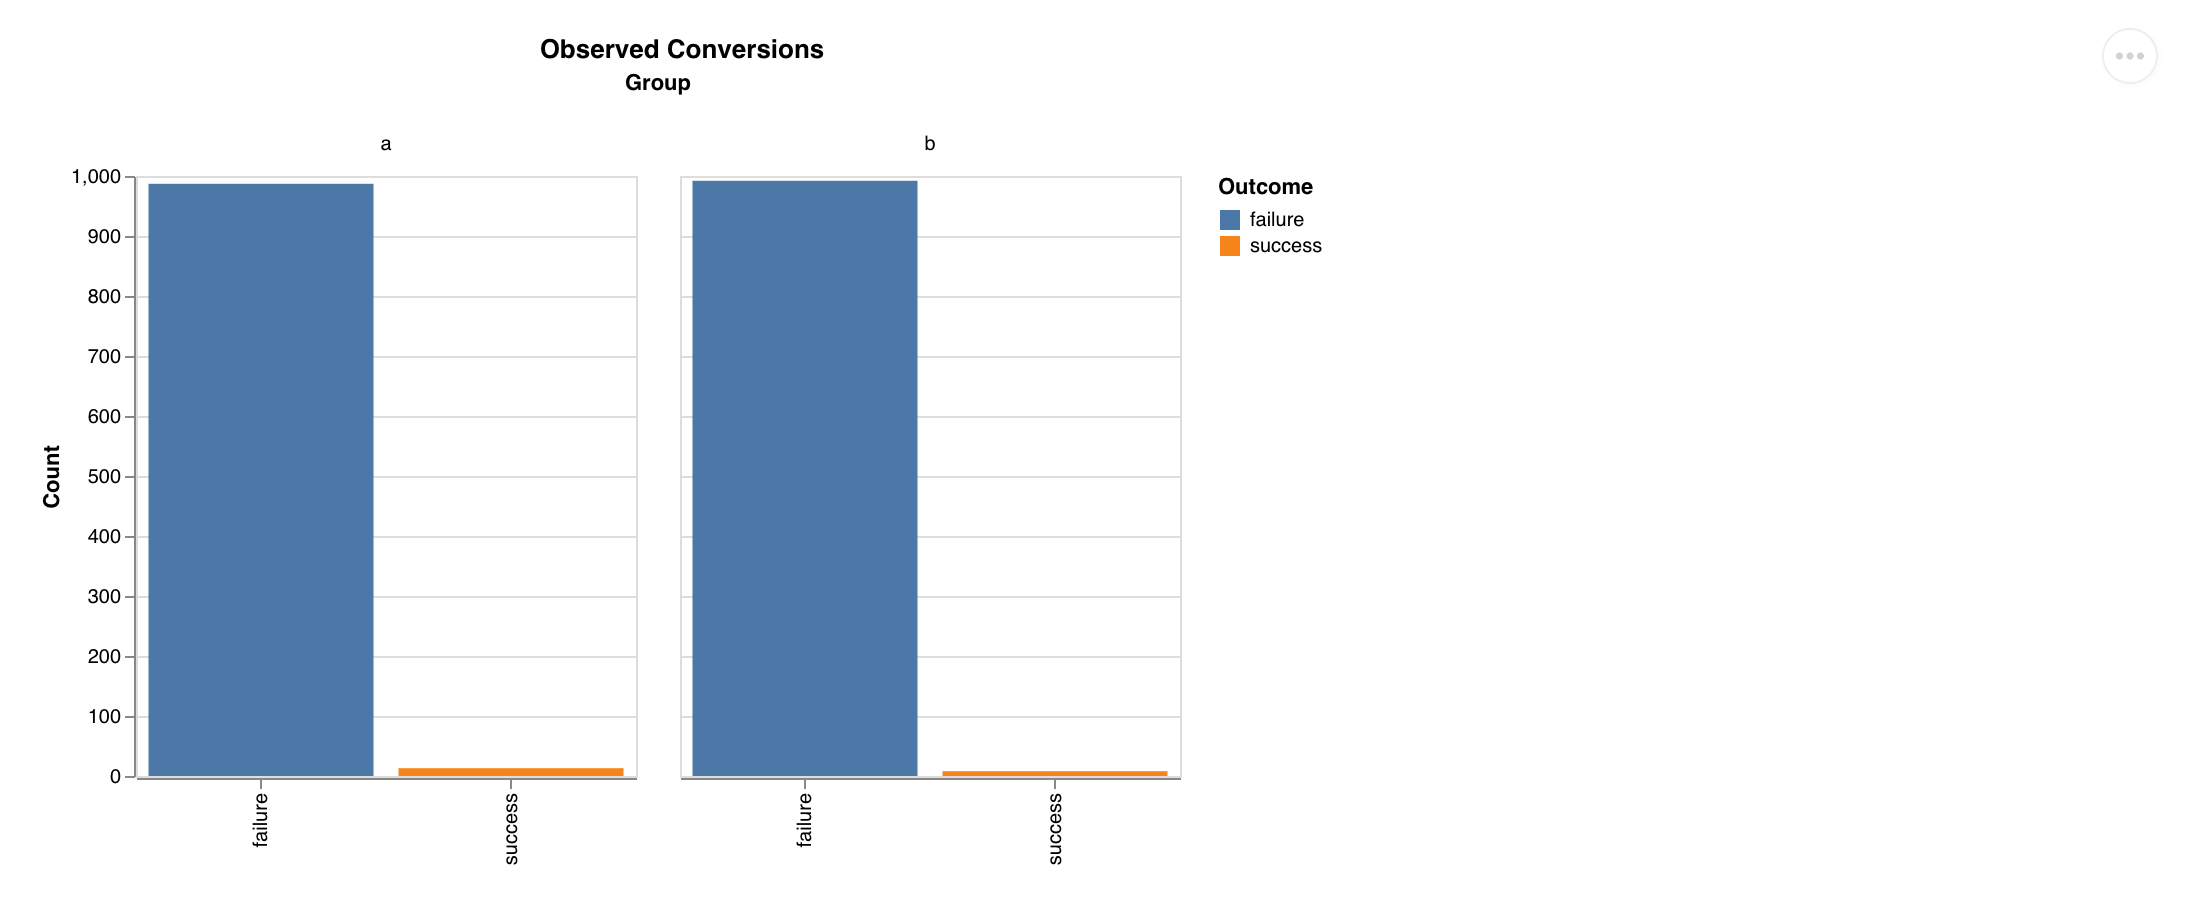

In [ ]:
# Aggregate binary outcomes into success/failure counts per group
successes_a = group_a.sum()
successes_b = group_b.sum()

failures_a = len(group_a) - successes_a
failures_b = len(group_b) - successes_b

samples_df = pl.DataFrame(
    {
        "group": ["a", "a", "b", "b"],
        "type": ["success", "failure", "success", "failure"],
        "count": [successes_a, failures_a, successes_b, failures_b],
    }
)

(
    alt.Chart(samples_df, title="Observed Conversions")
    .mark_bar()
    .encode(
        x=alt.X("type:N", title=""),
        y=alt.Y("count:Q", title="Count"),
        color=alt.Color("type:N", title="Outcome"),
        column=alt.Column("group:N", title="Group"),
    )
    .properties(width=250, height=300)
    .configure_title(anchor='middle')
)

### Summary Table

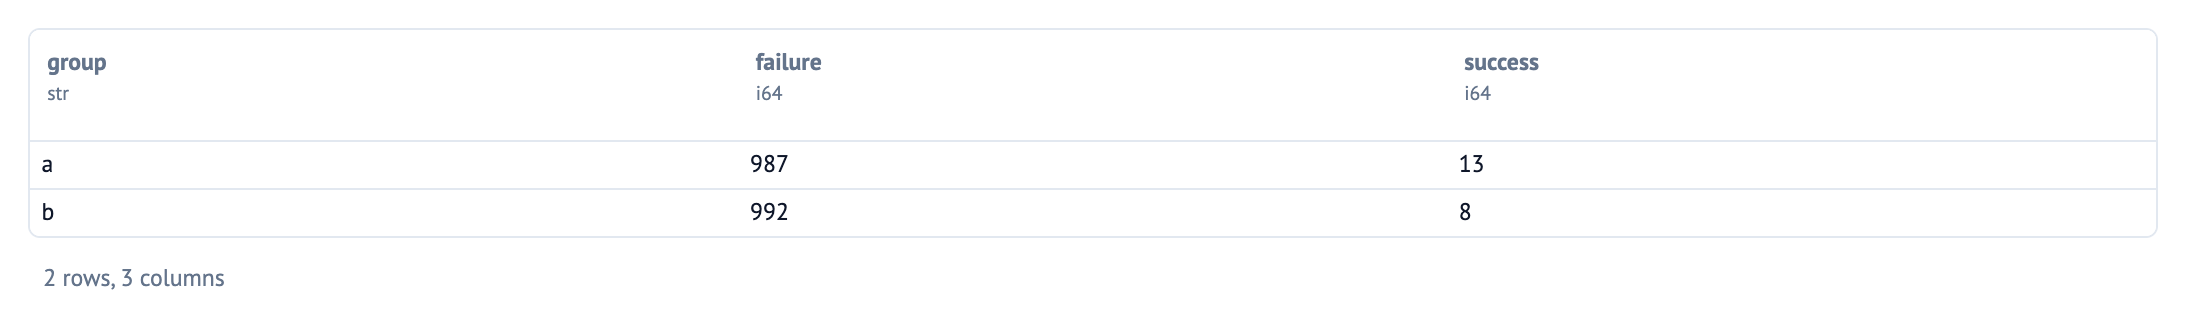

In [ ]:
samples_df.sort("type").pivot(index="group", on="type", values="count")

---

# Estimation: Posterior Distributions

## Bayesian Updating

The magic of Bayesian inference is **conjugacy**: when the prior is Beta and the data is Binomial,
the posterior is also Beta with updated parameters:

$$\alpha_{\text{posterior}} = \alpha_{\text{prior}} + \text{successes}$$

$$\beta_{\text{posterior}} = \beta_{\text{prior}} + \text{failures}$$

The posterior distribution represents our *updated belief* about the conversion rate after seeing the data.

## Frequentist Point Estimate

The frequentist approach simply uses the **sample mean** (successes / total) as the estimate.
There's no distribution—just a single point estimate.

In the chart below:
- **Solid lines**: Bayesian posterior distributions
- **Dots**: Maximum A Posteriori (MAP) estimates (peak of the posterior)
- **Dashed lines**: Frequentist sample means

In [ ]:
def beta_posterior_pdf(group: np.ndarray, prior_alpha: float, prior_beta: float, n_points: int = 500):
    """
    Compute the Beta posterior distribution using conjugacy.

    Returns: x values, PDF values, MAP estimate, and MAP density for plotting.
    """
    successes = group.sum()
    failures = len(group) - successes

    # Beta-Binomial conjugacy: posterior = Beta(α + successes, β + failures)
    posterior_alpha = prior_alpha + successes
    posterior_beta = prior_beta + failures

    posterior = stats.beta(posterior_alpha, posterior_beta)

    # Generate x values centered around the posterior mean (±4 std devs)
    mean = posterior.mean()
    std = posterior.std()
    x = np.linspace(max(0, mean - 4 * std), min(1, mean + 4 * std), n_points)
    pdf_values = posterior.pdf(x)

    # Find the MAP (Maximum A Posteriori) estimate - the mode of the posterior
    max_idx = np.argmax(pdf_values)
    map_estimate = x[max_idx]

    return x, pdf_values, map_estimate, pdf_values[max_idx]

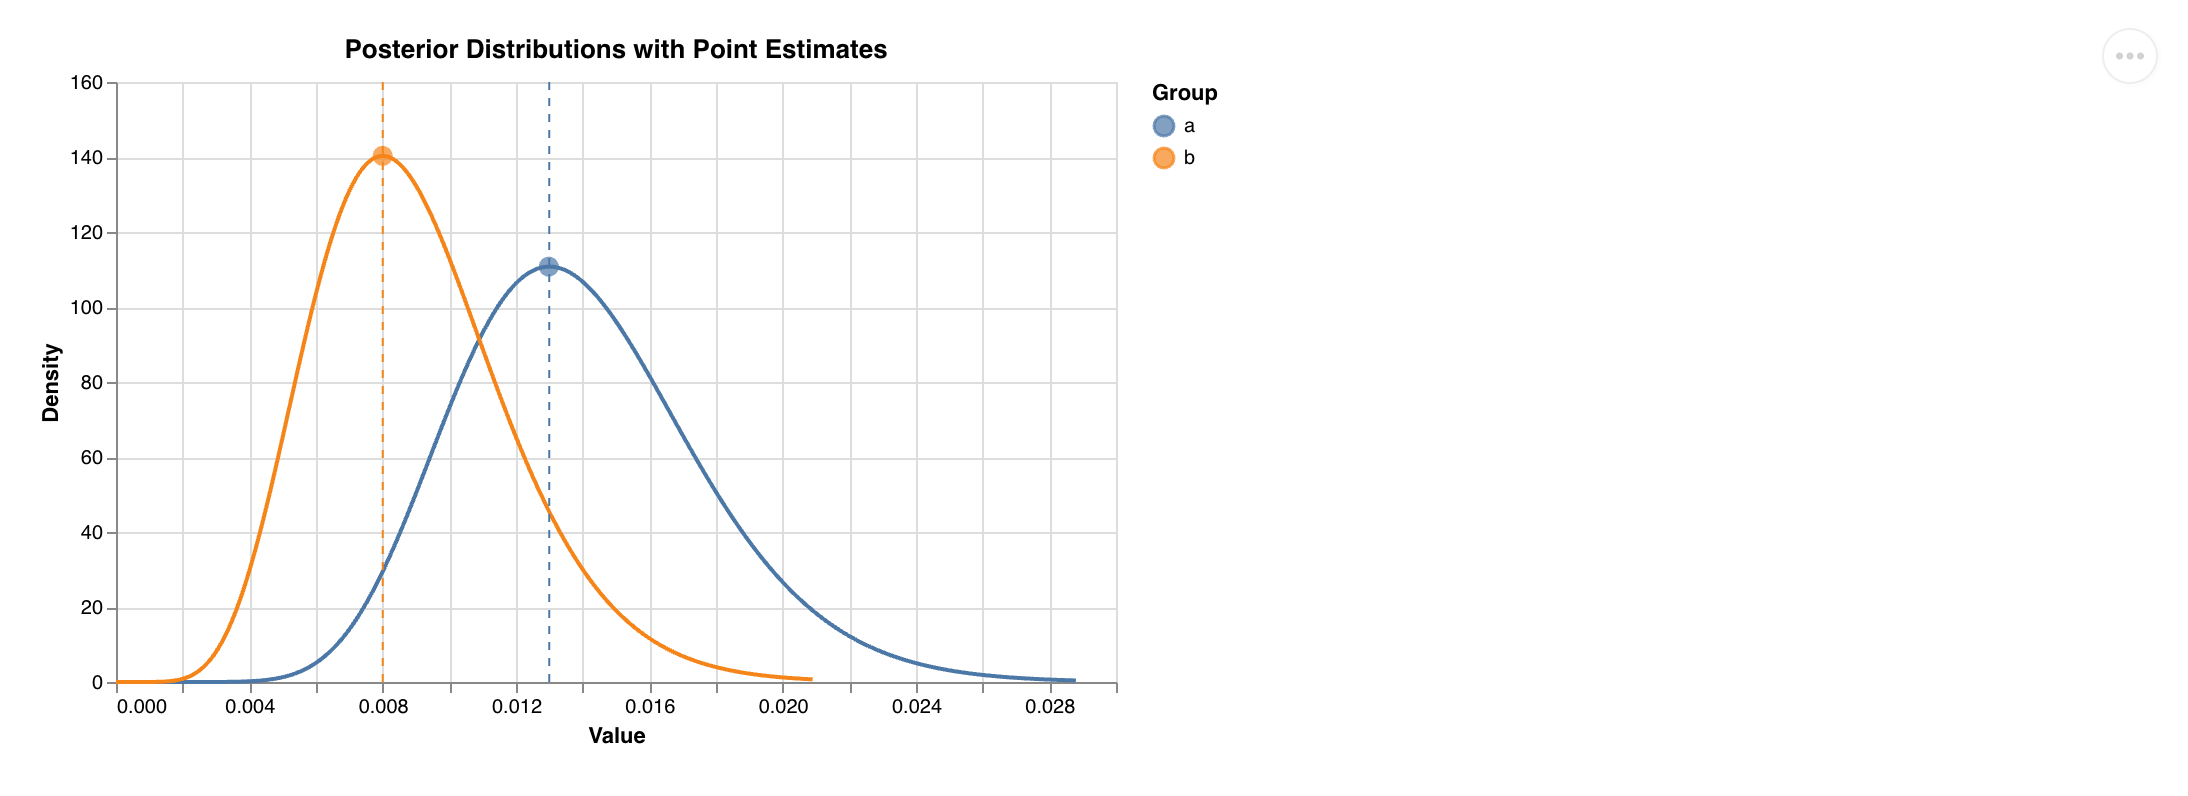

In [ ]:
x_a, pdf_a, map_a, map_density_a = beta_posterior_pdf(
    group_a, prior_alpha_a, prior_beta_a
)
x_b, pdf_b, map_b, map_density_b = beta_posterior_pdf(
    group_b, prior_alpha_b, prior_beta_b
)

posterior_df = pl.concat(
    [
        pl.DataFrame({"group": "a", "x": x_a, "density": pdf_a}),
        pl.DataFrame({"group": "b", "x": x_b, "density": pdf_b}),
    ]
)

map_df = pl.DataFrame(
    {
        "group": ["a", "b"],
        "x": [map_a, map_b],
        "density": [map_density_a, map_density_b],
    }
)

sample_mean_a = group_a.mean()
sample_mean_b = group_b.mean()

sample_mean_df = pl.DataFrame(
    {"group": ["a", "b"], "x": [sample_mean_a, sample_mean_b]}
)

lines = (
    alt.Chart(posterior_df)
    .mark_line()
    .encode(
        x=alt.X("x:Q", title="Value"),
        y=alt.Y("density:Q", title="Density"),
        color=alt.Color("group:N", title="Group"),
    )
)

points = (
    alt.Chart(map_df)
    .mark_point(size=100, filled=True)
    .encode(x="x:Q", y="density:Q", color="group:N")
)

sample_means = (
    alt.Chart(sample_mean_df)
    .mark_rule(strokeDash=[4, 4])
    .encode(x="x:Q", color="group:N")
)

(lines + points + sample_means).properties(
    width=500, height=300, title="Posterior Distributions with Point Estimates"
)

### Point Estimates Comparison

- **MAP (Maximum A Posteriori)**: The mode of the Bayesian posterior—most probable value given data + prior
- **Sample Mean**: The frequentist estimate—simply successes / total trials

With uniform priors and large samples, these values converge. With informative priors or small samples, they can differ significantly.

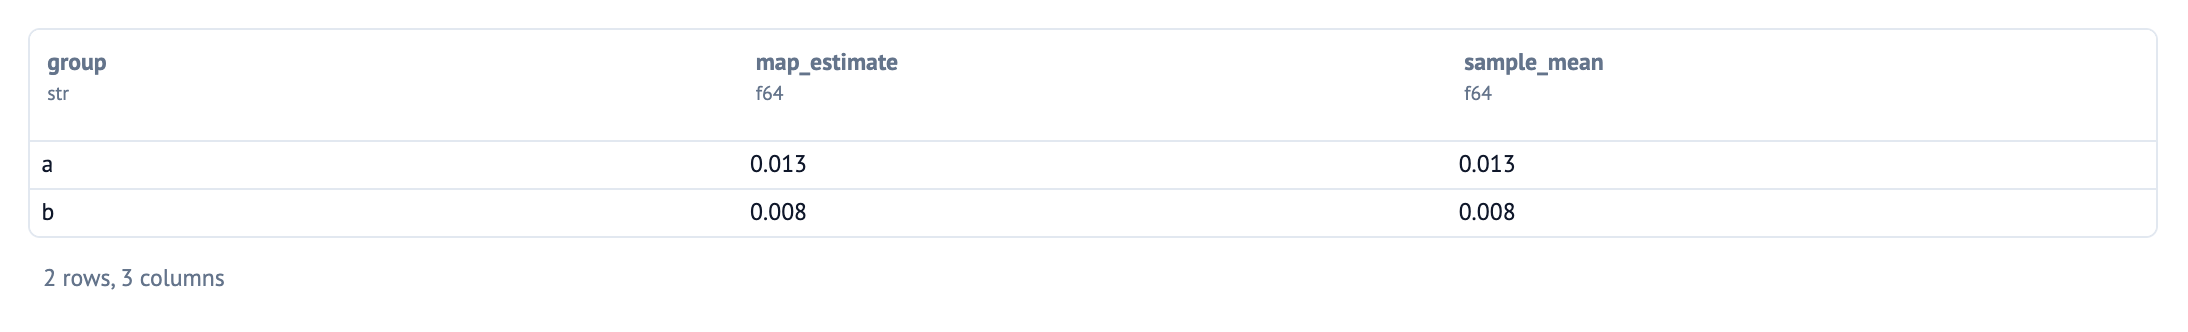

In [ ]:
(
    pl.DataFrame(
        {
            "group": ["a", "b"],
            "map_estimate": [map_a, map_b],
            "sample_mean": [sample_mean_a, sample_mean_b],
        }
    ).with_columns(pl.exclude("group").round(4))
)

---

# Statistical Testing: Is A Better Than B?

This is the key question in any A/B test. Let's compare how each paradigm answers it.

## Frequentist Approach: Hypothesis Testing

We use a **two-proportion z-test** with:
- **Null hypothesis (H₀)**: There is no difference (p_A = p_B)
- **Alternative hypothesis (H₁)**: A has a higher conversion rate (p_A > p_B)

The test computes a **p-value**: the probability of seeing data this extreme *if the null were true*.
If p < 0.05 (conventional threshold), we "reject the null" and declare statistical significance.

**Key limitation**: The p-value does NOT tell us the probability that A > B!

## Bayesian Approach: Direct Probability

We draw many samples from each posterior distribution and simply count:
"In what fraction of samples is A > B?"

This gives us exactly what we want: **P(A > B | data)**

In [ ]:
def two_proportion_ztest(group_a: np.ndarray, group_b: np.ndarray):
    """
    Frequentist two-proportion z-test.

    Tests H₀: p_A = p_B against H₁: p_A > p_B (one-sided)
    Returns the p-value for the one-sided test.
    """
    p_a, p_b = group_a.mean(), group_b.mean()
    n_a, n_b = len(group_a), len(group_b)

    # Pooled proportion under the null hypothesis
    p_pooled = (group_a.sum() + group_b.sum()) / (n_a + n_b)

    # Standard error of the difference
    se = np.sqrt(p_pooled * (1 - p_pooled) * (1 / n_a + 1 / n_b))

    # Z-statistic
    z_stat = (p_a - p_b) / se if se > 0 else 0

    # One-sided p-value: P(Z > z_stat) under H₀
    return stats.norm.sf(z_stat)

In [ ]:
# Bayesian: Monte Carlo estimation of P(A > B)
# Draw samples from each posterior and count how often A > B
def probability_test(
    group_a: np.ndarray,
    group_b: np.ndarray,
    prior_alpha_a=1,
    prior_beta_a=1,
    prior_alpha_b=1,
    prior_beta_b=1,
    seed=42,
):
    rng = np.random.default_rng(seed)

    # Posterior parameters using Beta-Binomial conjugacy
    alpha_a = prior_alpha_a + group_a.sum()
    beta_a = prior_beta_a + len(group_a) - group_a.sum()

    alpha_b = prior_alpha_b + group_b.sum()
    beta_b = prior_beta_b + len(group_b) - group_b.sum()

    # Draw 100k samples from each posterior
    samples_a = stats.beta(alpha_a, beta_a).rvs(100_000, random_state=rng)
    samples_b = stats.beta(alpha_b, beta_b).rvs(100_000, random_state=rng)

    # P(A > B) = fraction of samples where A > B
    return (samples_a > samples_b).mean()

In [ ]:
# Compute both frequentist p-value and Bayesian probability
pvalue_a_better = two_proportion_ztest(group_a, group_b)
prob_a_better = probability_test(
    group_a, group_b, prior_alpha_a, prior_beta_a, prior_alpha_b, prior_beta_b
)

In [ ]:
# Format results in human-readable language
def interpret_frequentist(pvalue: float, alpha: float = 0.05):
    if pvalue < alpha:
        result = f"We reject the null hypothesis (p = {pvalue:.4f} < {alpha}). There is statistically significant evidence that A > B."
    else:
        result = f"We fail to reject the null hypothesis (p = {pvalue:.4f} >= {alpha}). There is no statistically significant evidence that A > B."
    return mo.md(f"**Frequentist:** {result}")

def interpret_bayesian(prob: float):
    return mo.md(
        f"**Bayesian:** There is a {prob * 100:.1f}% probability that A > B."
    )

## Conclusions

Compare the two approaches below. Notice how the Bayesian result gives a direct probability
that's intuitive to interpret, while the frequentist result requires understanding of hypothesis testing conventions.

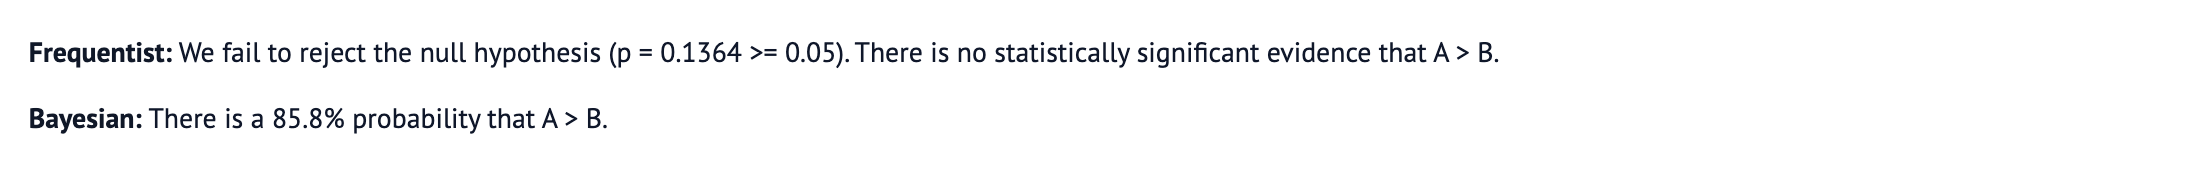

In [ ]:
mo.vstack(
    [interpret_frequentist(pvalue_a_better), interpret_bayesian(prob_a_better)]
)

---

# Key Takeaways

| Aspect | Frequentist | Bayesian |
|--------|-------------|----------|
| **What it answers** | "How surprising is this data if H₀ is true?" | "What's the probability A > B?" |
| **Output** | p-value (requires threshold interpretation) | Direct probability |
| **Prior knowledge** | Not incorporated | Can use informative priors |
| **Small samples** | Unreliable estimates | Priors help regularize |
| **Interpretation** | Often misunderstood | Intuitive |

## When to Use Each

**Prefer Frequentist when:**
- Regulatory/scientific contexts requiring p-values
- You need to control false positive rates precisely
- Large sample sizes are available

**Prefer Bayesian when:**
- Business decisions need clear probability statements
- You have reliable prior information
- Sample sizes are small
- Stakeholders need intuitive results

## Common Pitfalls to Avoid

1. **Misinterpreting p-values**: p = 0.03 does NOT mean "3% chance the null is true"
2. **Ignoring priors' influence**: With small data, priors dominate—choose them carefully
3. **Multiple testing**: Running many tests inflates false positives (frequentist) or requires prior adjustments (Bayesian)
4. **Stopping early**: Frequentist tests assume fixed sample size; Bayesian methods handle continuous monitoring better